In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd

DATASET_ROOT = "/content/drive/MyDrive/BATTERY_SOC_PROJECT/Dataset_Li-ion"
FROZEN_DIR = f"/content/drive/MyDrive/frozen_dataset"
FEATURE_DIR = f"/content/drive/MyDrive/feature_engineering_v1"

TRAIN_PATH = f"/content/drive/MyDrive/frozen_dataset/dataset_v1_train.csv"
TEST_PATH = f"/content/drive/MyDrive/frozen_dataset/dataset_v1_test.csv"
ENGINEERED_PATH = f"/content/drive/MyDrive/feature_engineering_v1/engineered_dataset.csv"

for p in [TRAIN_PATH, TEST_PATH]:
    assert os.path.exists(p), f"Couldn't find {p} — check the Day 12 copy step."

TARGET_COLUMN = "soc_percent"
RAW_FEATURES = ["voltage_v", "current_a", "cell_temp_c", "power_w", "ambient_temp_c"]

df_train_raw = pd.read_csv(TRAIN_PATH)
df_test_raw = pd.read_csv(TEST_PATH)
print(f"Frozen split loaded — train: {df_train_raw.shape}, test: {df_test_raw.shape}")


HAVE_ENGINEERED = os.path.exists(ENGINEERED_PATH)
if HAVE_ENGINEERED:
    df_eng_full = pd.read_csv(ENGINEERED_PATH)
    print(f"Engineered dataset found: {df_eng_full.shape}")
else:
    print("⚠️  Engineered dataset not found at the expected path — "
          "only the raw-feature baselines will run. Copy Day 13's "
          "feature_engineering_v1/ folder to Drive to include it.")

Frozen split loaded — train: (76792, 7), test: (27768, 7)
Engineered dataset found: (104525, 5)


In [3]:
ENGINEERED_FEATURES = None
if HAVE_ENGINEERED:
    key_cols = ["file_id", "timestamp"]
    eng_cols = [c for c in df_eng_full.columns if c not in key_cols + [TARGET_COLUMN]]

    train_keys = df_train_raw[["file_id"]].drop_duplicates()
    test_keys = df_test_raw[["file_id"]].drop_duplicates()


    df_eng_train = df_eng_full[df_eng_full["file_id"].isin(train_keys["file_id"])].copy()
    df_eng_test = df_eng_full[df_eng_full["file_id"].isin(test_keys["file_id"])].copy()

    ENGINEERED_FEATURES = eng_cols
    print(f"Engineered features available for baselines ({len(ENGINEERED_FEATURES)}): {ENGINEERED_FEATURES}")
    print(f"Engineered train/test after routing by file_id: "
          f"{df_eng_train.shape} / {df_eng_test.shape}")

Engineered features available for baselines (2): ['voltage_roll_std5', 'current_roll_std5']
Engineered train/test after routing by file_id: (76764, 5) / (27761, 5)


In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def score(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"[{label}] MAE={mae:.3f} SOC%  RMSE={rmse:.3f} SOC%  R2={r2:.4f}")
    return {"label": label, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []

In [5]:
y_train = df_train_raw[TARGET_COLUMN]
y_test = df_test_raw[TARGET_COLUMN]

mean_pred_value = y_train.mean()
y_pred_mean = np.full_like(y_test, fill_value=mean_pred_value, dtype=float)

print("===== BASELINE 0: MEAN PREDICTOR =====")
print(f"Training mean SOC: {mean_pred_value:.3f}%")
results.append(score(y_test, y_pred_mean, "Mean baseline"))

===== BASELINE 0: MEAN PREDICTOR =====
Training mean SOC: 60.884%
[Mean baseline] MAE=23.041 SOC%  RMSE=27.509 SOC%  R2=-0.0476


In [6]:
from sklearn.linear_model import LinearRegression

X_train_raw = df_train_raw[RAW_FEATURES]
X_test_raw = df_test_raw[RAW_FEATURES]

lr_raw = LinearRegression()
lr_raw.fit(X_train_raw, y_train)
y_pred_lr_raw = lr_raw.predict(X_test_raw)

print("\n===== BASELINE 1: LINEAR REGRESSION (raw features) =====")
results.append(score(y_test, y_pred_lr_raw, "Linear — raw"))
print("Coefficients:")
for feat, coef in zip(RAW_FEATURES, lr_raw.coef_):
    print(f"  {feat}: {coef:.4f}")
print(f"  intercept: {lr_raw.intercept_:.4f}")


===== BASELINE 1: LINEAR REGRESSION (raw features) =====
[Linear — raw] MAE=3.473 SOC%  RMSE=4.586 SOC%  R2=0.9709
Coefficients:
  voltage_v: 92.9482
  current_a: -1.4060
  cell_temp_c: 1.5608
  power_w: -0.1638
  ambient_temp_c: 0.0000
  intercept: -327.3220


In [7]:
y_pred_lr_eng = None
if HAVE_ENGINEERED:
    X_train_eng = df_eng_train[ENGINEERED_FEATURES]
    y_train_eng = df_eng_train[TARGET_COLUMN]
    X_test_eng = df_eng_test[ENGINEERED_FEATURES]
    y_test_eng = df_eng_test[TARGET_COLUMN]

    lr_eng = LinearRegression()
    lr_eng.fit(X_train_eng, y_train_eng)
    y_pred_lr_eng = lr_eng.predict(X_test_eng)

    print("\n===== BASELINE 2: LINEAR REGRESSION (engineered features) =====")
    results.append(score(y_test_eng, y_pred_lr_eng, "Linear — engineered"))
else:
    print("\n(Skipping engineered baseline — engineered_dataset.csv not found.)")


===== BASELINE 2: LINEAR REGRESSION (engineered features) =====
[Linear — engineered] MAE=23.193 SOC%  RMSE=27.771 SOC%  R2=-0.0681


In [8]:
results_df = pd.DataFrame(results).set_index("label")
results_df["MAE_improvement_vs_mean_%"] = 100 * (
    results_df.loc["Mean baseline", "MAE"] - results_df["MAE"]
) / results_df.loc["Mean baseline", "MAE"]

print("\n===== BASELINE COMPARISON =====")
print(results_df.to_string())


===== BASELINE COMPARISON =====
                           MAE       RMSE        R2  MAE_improvement_vs_mean_%
label                                                                         
Mean baseline        23.041381  27.508849 -0.047575                   0.000000
Linear — raw          3.472758   4.585786  0.970888                  84.928169
Linear — engineered  23.193436  27.771279 -0.068143                  -0.659925


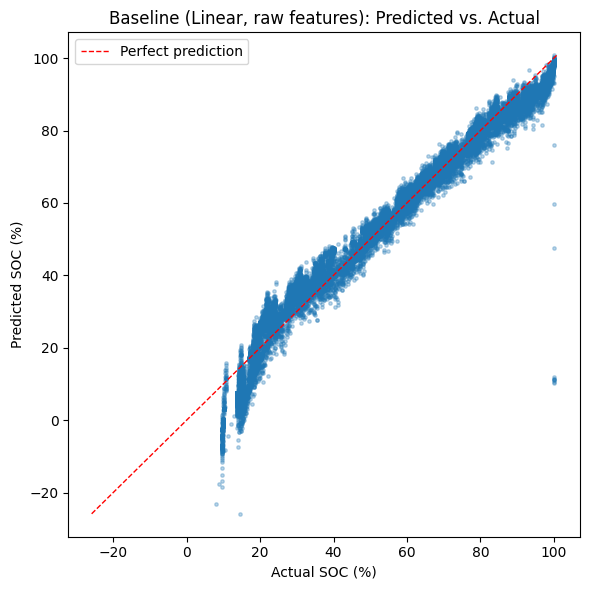

In [9]:
import matplotlib.pyplot as plt

os.makedirs("baseline_v1", exist_ok=True)


plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lr_raw, s=6, alpha=0.3)
lims = [min(y_test.min(), y_pred_lr_raw.min()), max(y_test.max(), y_pred_lr_raw.max())]
plt.plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
plt.xlabel("Actual SOC (%)")
plt.ylabel("Predicted SOC (%)")
plt.title("Baseline (Linear, raw features): Predicted vs. Actual")
plt.legend()
plt.tight_layout()
plt.savefig("baseline_v1/pred_vs_actual_raw.png", dpi=150)
plt.show()

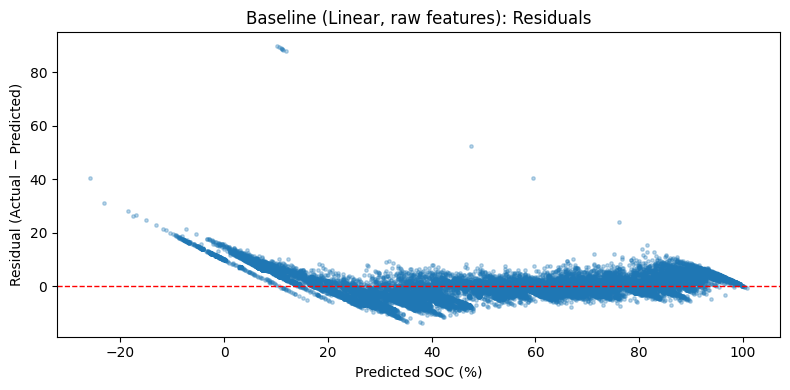

In [10]:
residuals_raw = y_test.values - y_pred_lr_raw
plt.figure(figsize=(8, 4))
plt.scatter(y_pred_lr_raw, residuals_raw, s=6, alpha=0.3)
plt.axhline(0, color="r", linestyle="--", linewidth=1)
plt.xlabel("Predicted SOC (%)")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Baseline (Linear, raw features): Residuals")
plt.tight_layout()
plt.savefig("baseline_v1/residuals_raw.png", dpi=150)
plt.show()

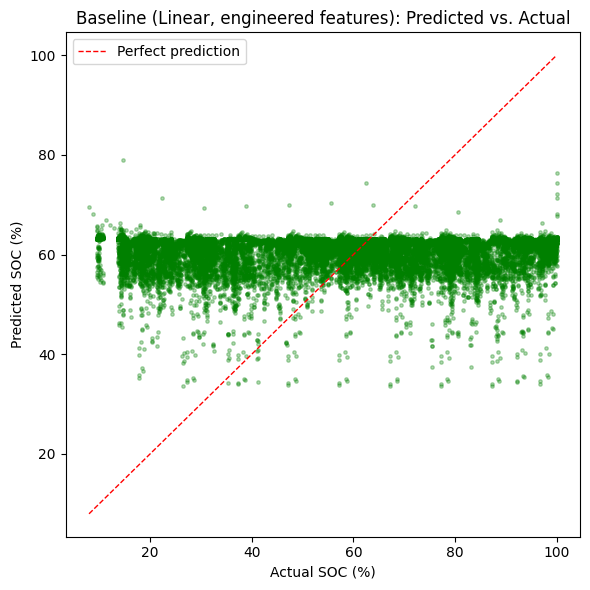

In [11]:
if HAVE_ENGINEERED:
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test_eng, y_pred_lr_eng, s=6, alpha=0.3, color="green")
    lims = [min(y_test_eng.min(), y_pred_lr_eng.min()), max(y_test_eng.max(), y_pred_lr_eng.max())]
    plt.plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
    plt.xlabel("Actual SOC (%)")
    plt.ylabel("Predicted SOC (%)")
    plt.title("Baseline (Linear, engineered features): Predicted vs. Actual")
    plt.legend()
    plt.tight_layout()
    plt.savefig("baseline_v1/pred_vs_actual_engineered.png", dpi=150)
    plt.show()


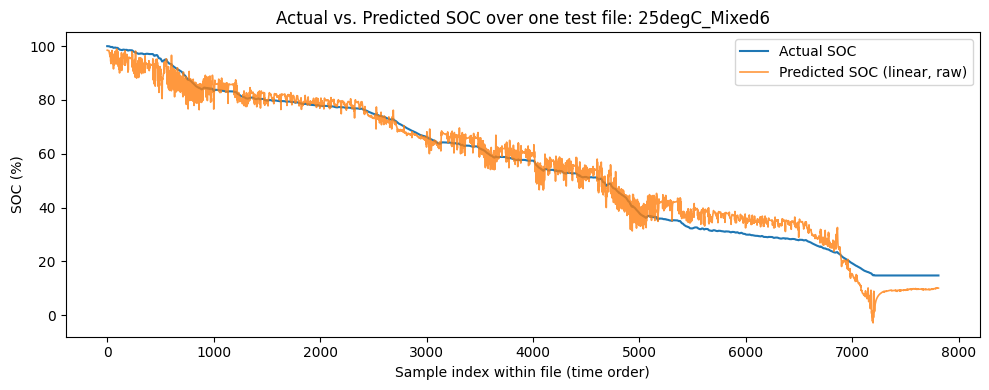


✅ Plots saved in 'baseline_v1/':
 - pred_vs_actual_engineered.png
 - pred_vs_actual_raw.png
 - residuals_raw.png
 - trace_single_file.png


In [12]:
sample_file = df_test_raw["file_id"].value_counts().index[0]
mask = df_test_raw["file_id"] == sample_file
df_sample = df_test_raw[mask].reset_index(drop=True)
y_sample_pred = lr_raw.predict(df_sample[RAW_FEATURES])

plt.figure(figsize=(10, 4))
plt.plot(df_sample[TARGET_COLUMN].values, label="Actual SOC", linewidth=1.5)
plt.plot(y_sample_pred, label="Predicted SOC (linear, raw)", linewidth=1.2, alpha=0.8)
plt.xlabel("Sample index within file (time order)")
plt.ylabel("SOC (%)")
plt.title(f"Actual vs. Predicted SOC over one test file: {sample_file}")
plt.legend()
plt.tight_layout()
plt.savefig("baseline_v1/trace_single_file.png", dpi=150)
plt.show()

print("\n✅ Plots saved in 'baseline_v1/':")
for f in sorted(os.listdir("baseline_v1")):
    if f.endswith(".png"):
        print(" -", f)

In [13]:
import datetime

results_df.to_csv("baseline_v1/baseline_metrics.csv")

with open("baseline_v1/summary.txt", "w") as f:
    f.write("Day 15 — Baseline Modelling + Mentor Review\n")
    f.write(f"Generated: {datetime.datetime.now()}\n\n")
    f.write("Split used: FROZEN Dataset V1 split from Day 12 (GroupShuffleSplit "
            "by file_id, test_size=0.2, random_state=42) — not re-split here.\n\n")
    f.write("Agreed metrics: MAE (SOC%), RMSE (SOC%), R^2\n\n")
    f.write("Baseline results:\n")
    f.write(results_df.to_string())
    f.write("\n\nModelling direction:\n")
    if HAVE_ENGINEERED and results_df.loc["Linear — engineered", "MAE"] < results_df.loc["Linear — raw", "MAE"]:
        f.write(" - Engineered features already beat raw features on a plain linear model,\n"
                "   so the Day 13 feature set carries real signal — worth carrying forward\n"
                "   into a non-linear model (e.g. Random Forest) next.\n")
    elif HAVE_ENGINEERED:
        f.write(" - Engineered features did NOT beat raw features on a plain linear model.\n"
                "   Flag for mentor: is this a sign the engineered features need revisiting,\n"
                "   or that a non-linear model is needed before the benefit shows up?\n")
    else:
        f.write(" - Engineered feature comparison pending — copy feature_engineering_v1/\n"
                "   to Drive and re-run to complete this baseline set.\n")
    f.write(" - Both linear baselines are expected to beat the mean baseline by a wide\n"
            "   margin; if not, that's a red flag to raise with the mentor before\n"
            "   investing time in more complex models.\n")

print("\n✅ Baseline artifacts saved in 'baseline_v1/':")
for f in os.listdir("baseline_v1"):
    print(" -", f)


✅ Baseline artifacts saved in 'baseline_v1/':
 - pred_vs_actual_engineered.png
 - baseline_metrics.csv
 - pred_vs_actual_raw.png
 - residuals_raw.png
 - summary.txt
 - trace_single_file.png


In [14]:
import shutil
shutil.copytree("baseline_v1", "/content/drive/MyDrive/Dataset_Li-ion/baseline_v1", dirs_exist_ok=True)

'/content/drive/MyDrive/Dataset_Li-ion/baseline_v1'